##IMPORT LIBRARY & LOAD

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy import stats
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import joblib
import json


In [2]:
df = pd.read_csv("food_price_anomalies (2).csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4894 entries, 0 to 4893
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REF_AREA_LABEL          4894 non-null   object 
 1   TIME_PERIOD             4894 non-null   int64  
 2   OBS_VALUE               4894 non-null   float64
 3   INDICATOR_LABEL         4894 non-null   object 
 4   COMP_BREAKDOWN_1_LABEL  4894 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 191.3+ KB


In [3]:
df.sample(10
          )

,REF_AREA_LABEL,TIME_PERIOD,OBS_VALUE,INDICATOR_LABEL,COMP_BREAKDOWN_1_LABEL
1365,Finland,2012,0.51,2.c.1 Indicator of food price anomalies,Sub-indicator: Consumer Food Price Index
989,Sri Lanka,2017,1.14,2.c.1 Indicator of food price anomalies,Sub-indicator: Consumer Food Price Index
4626,Eswatini,2015,0.12,2.c.1 Indicator of food price anomalies,Sub-indicator: Type of product
1362,Fiji,2023,0.87,2.c.1 Indicator of food price anomalies,Sub-indicator: Consumer Food Price Index
2204,Saudi Arabia,2014,-0.64,2.c.1 Indicator of food price anomalies,Sub-indicator: Consumer Food Price Index
3969,Mauritania,2018,-0.05,2.c.1 Indicator of food price anomalies,Sub-indicator: Type of product
2200,Saudi Arabia,2010,0.19,2.c.1 Indicator of food price anomalies,Sub-indicator: Consumer Food Price Index
4364,Romania,2015,-0.14,2.c.1 Indicator of food price anomalies,Sub-indicator: Type of product
145,Angola,2012,-0.26,2.c.1 Indicator of food price anomalies,Sub-indicator: Consumer Food Price Index
4712,Tunisia,2019,-0.50,2.c.1 Indicator of food price anomalies,Sub-indicator: Type of product


In [4]:
df_pivot = df.pivot_table(
    index='REF_AREA_LABEL',
    columns='TIME_PERIOD',
    values='OBS_VALUE',
    aggfunc='mean'
).reset_index()

print(f"Pivoted shape: {df_pivot.shape}")

Pivoted shape: (202, 16)


In [5]:
df_pivot.sample(10)

TIME_PERIOD,REF_AREA_LABEL,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
6,Anguilla,-2.42,-0.53,-0.34,-0.09,0.01,-0.540000,-0.7000,-0.600000,-0.210000,0.100000,0.040000,0.290000,1.750000,1.140000,NaN
47,Costa Rica,-0.91,-0.40,-0.65,-0.37,-0.03,0.202500,-0.2875,-0.017500,-0.170000,0.092500,0.030000,0.477500,1.615000,0.140000,0.640
85,Iceland,-0.60,-0.12,0.08,-0.02,-0.70,0.380000,-0.4100,-1.460000,0.140000,0.220000,0.790000,-0.500000,-0.190000,0.990000,NaN
194,Uzbekistan,0.19,0.43,-0.61,-0.38,-1.09,-3.640000,-8.5400,4.120000,0.540000,-0.290000,0.440000,0.100000,0.100000,-0.480000,NaN
152,Russian Federation,-0.15,-0.02,-0.53,-0.34,0.71,1.423333,-0.7700,-0.606667,-0.273333,0.776667,0.680000,0.430000,-0.130000,-2.006667,1.815
29,Brunei Darussalam,-6.47,0.05,0.10,-0.30,-1.22,2.240000,-0.3800,1.560000,0.560000,-0.620000,0.440000,0.220000,0.990000,1.380000,NaN
117,Mauritania,2.13,-0.88,-2.17,0.36,1.05,-0.006667,0.6200,-0.590000,-0.616667,-0.040000,-0.543333,0.593333,2.766667,-0.916667,-0.485
65,Finland,-1.90,0.49,0.51,0.56,-0.70,-0.330000,-0.5650,-0.015000,0.410000,-0.435000,0.310000,0.205000,1.660000,-1.435000,0.530
148,Puerto Rico,-1.26,-0.32,0.01,0.02,0.52,1.160000,-0.3000,-0.960000,-0.320000,-0.390000,0.030000,-0.080000,1.140000,1.050000,NaN
122,Mongolia,0.23,-0.09,0.47,-0.30,-0.81,-0.050000,-0.0300,-0.013333,-0.130000,0.726667,0.276667,0.326667,0.300000,0.683333,-0.485


## FEATURE ENGINEERING

In [6]:


def calculate_volatility_features(country_data):
    """Calculate volatility-related features"""
    years = country_data['TIME_PERIOD'].values
    values = country_data['OBS_VALUE'].values

    # Sort by year
    sort_idx = np.argsort(years)
    years = years[sort_idx]
    values = values[sort_idx]

    features = {}

    # Basic volatility measures
    features['volatility_std'] = np.std(values) if len(values) > 1 else 0
    features['volatility_mad'] = np.mean(np.abs(values - np.mean(values))) if len(values) > 0 else 0  # Mean Absolute Deviation

    # Rolling volatility (if we have enough data points)
    if len(values) >= 3:
        rolling_std = [np.std(values[max(0, i-2):i+1]) for i in range(len(values))]
        features['volatility_rolling_max'] = np.max(rolling_std)
        features['volatility_rolling_avg'] = np.mean(rolling_std)
    else:
        features['volatility_rolling_max'] = features['volatility_std']
        features['volatility_rolling_avg'] = features['volatility_std']

    # Volatility clusters (periods of high instability)
    if len(values) > 1:
        changes = np.diff(values)
        features['high_volatility_periods'] = np.sum(np.abs(changes) > 1.0)  # Count big swings
        features['volatility_persistence'] = np.mean(np.abs(changes))  # Average change magnitude
    else:
        features['high_volatility_periods'] = 0
        features['volatility_persistence'] = 0

    return features

In [7]:
def calculate_extreme_features(country_data):
    """Calculate features related to extreme price movements"""
    values = country_data['OBS_VALUE'].values

    features = {}

    # Extreme value thresholds (adjust based on your data distribution)
    extreme_positive_threshold = 1.5   # High positive anomalies
    extreme_negative_threshold = -1.5  # High negative anomalies
    crisis_threshold = 2.0             # Crisis-level anomalies

    # Count extreme events
    features['extreme_positive_count'] = np.sum(values > extreme_positive_threshold)
    features['extreme_negative_count'] = np.sum(values < extreme_negative_threshold)
    features['crisis_events'] = np.sum(np.abs(values) > crisis_threshold)
    features['total_extreme_events'] = features['extreme_positive_count'] + features['extreme_negative_count']

    # Magnitude of extremes
    if len(values) > 0:
        features['max_positive_extreme'] = np.max(values) if np.max(values) > extreme_positive_threshold else 0
        features['max_negative_extreme'] = np.min(values) if np.min(values) < extreme_negative_threshold else 0
        features['avg_extreme_magnitude'] = np.mean(values[np.abs(values) > 1.0]) if np.any(np.abs(values) > 1.0) else 0
    else:
        features['max_positive_extreme'] = 0
        features['max_negative_extreme'] = 0
        features['avg_extreme_magnitude'] = 0

    # Extreme event density (events per year)
    years_span = len(country_data['TIME_PERIOD'].unique())
    features['extreme_density'] = features['total_extreme_events'] / years_span if years_span > 0 else 0

    return features

In [8]:
def calculate_stability_features(country_data):
    """Calculate stability and resilience features"""
    years = country_data['TIME_PERIOD'].values
    values = country_data['OBS_VALUE'].values

    # Sort by year
    sort_idx = np.argsort(years)
    years = years[sort_idx]
    values = values[sort_idx]

    features = {}

    # Basic stability measures
    features['stability_inverse_volatility'] = 1 / (np.std(values) + 0.001)  # Avoid division by zero

    # Time in normal range (between -1 and 1)
    normal_range_count = np.sum((values >= -1.0) & (values <= 1.0))
    features['time_in_normal_range'] = normal_range_count / len(values) if len(values) > 0 else 0

    # Recovery speed (how quickly values return to normal after extremes)
    if len(values) > 1:
        recovery_speeds = []
        for i in range(1, len(values)):
            if np.abs(values[i-1]) > 1.0 and np.abs(values[i]) <= 1.0:  # Extreme to normal
                recovery_speeds.append(1)  # Recovered in one year
            elif np.abs(values[i-1]) > 1.0 and np.abs(values[i]) > 1.0:  # Still extreme
                recovery_speeds.append(0)  # No recovery
        features['recovery_speed'] = np.mean(recovery_speeds) if recovery_speeds else 1.0
    else:
        features['recovery_speed'] = 1.0

    # Consistency score (lower values = more consistent)
    if len(values) > 1:
        features['consistency_score'] = 1 / (1 + np.mean(np.abs(np.diff(values))))
    else:
        features['consistency_score'] = 1.0

    # Resilience index (combination of stability measures)
    features['resilience_index'] = (
        features['stability_inverse_volatility'] * 0.4 +
        features['time_in_normal_range'] * 0.3 +
        features['recovery_speed'] * 0.3
    )

    return features

In [9]:
# Create the comprehensive feature set
feature_records = []

for country in df['REF_AREA_LABEL'].unique():
    country_data = df[df['REF_AREA_LABEL'] == country]

    # Calculate features from each category
    volatility_features = calculate_volatility_features(country_data)
    extreme_features = calculate_extreme_features(country_data)
    stability_features = calculate_stability_features(country_data)

    # Combine all features
    country_features = {
        'country': country,
        **volatility_features,
        **extreme_features,
        **stability_features
    }

    feature_records.append(country_features)

# Create final feature dataframe
features_df = pd.DataFrame(feature_records)

print(f"Final features shape: {features_df.shape}")
print(f"Countries: {len(features_df)}")
print(f"Features: {features_df.shape[1] - 1}")  # Excluding country column

# Display feature summary
print("\nFeature Summary:")
features_df.describe()

Final features shape: (202, 20)
Countries: 202
Features: 19

Feature Summary:


,volatility_std,volatility_mad,volatility_rolling_max,volatility_rolling_avg,high_volatility_periods,volatility_persistence,extreme_positive_count,extreme_negative_count,crisis_events,total_extreme_events,max_positive_extreme,max_negative_extreme,avg_extreme_magnitude,extreme_density,stability_inverse_volatility,time_in_normal_range,recovery_speed,consistency_score,resilience_index
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,1.294605,0.838114,2.404787,0.683757,7.341584,1.077059,1.529703,1.178218,1.524752,2.707921,2.725099,-2.815743,0.111807,0.185316,1.110587,0.775217,0.721924,0.520099,0.893377
std,1.536860,0.743047,3.530450,0.593356,4.817790,0.885304,1.681509,1.276625,1.719621,2.422703,5.787875,5.379963,1.640131,0.163274,0.482422,0.114557,0.245056,0.110328,0.265391
min,0.374599,0.255000,0.360000,0.201583,0.000000,0.306154,0.000000,0.000000,0.000000,0.000000,0.000000,-55.710000,-10.888333,0.000000,0.067701,0.428571,0.000000,0.095420,0.309963
25%,0.740799,0.545967,1.015930,0.433092,4.000000,0.692448,0.000000,0.000000,0.000000,1.000000,0.000000,-3.067500,-0.517500,0.071429,0.829284,0.705882,0.500000,0.467339,0.710639
50%,0.923964,0.674972,1.460090,0.549881,7.000000,0.878488,1.000000,1.000000,1.000000,2.000000,1.975000,-1.890000,0.000000,0.142857,1.081124,0.785714,0.714286,0.532343,0.878264
75%,1.204865,0.865973,2.323596,0.711486,10.000000,1.139819,2.000000,2.000000,2.000000,4.000000,2.905000,0.000000,0.676167,0.266667,1.348078,0.857143,1.000000,0.590860,1.050470
max,14.769886,8.771837,31.805998,6.379753,25.000000,9.480000,8.000000,6.000000,8.000000,12.000000,65.230000,0.000000,10.260000,0.800000,2.662413,1.000000,1.000000,0.765607,1.664965


In [10]:
features_df

,country,volatility_std,volatility_mad,volatility_rolling_max,volatility_rolling_avg,high_volatility_periods,volatility_persistence,extreme_positive_count,extreme_negative_count,crisis_events,total_extreme_events,max_positive_extreme,max_negative_extreme,avg_extreme_magnitude,extreme_density,stability_inverse_volatility,time_in_normal_range,recovery_speed,consistency_score,resilience_index
0,Haiti,0.733855,0.584590,1.093526,0.465338,11,0.693125,2,0,0,2,1.80,0.00,1.103333,0.142857,1.360812,0.816327,0.875000,0.590624,1.051723
1,Honduras,0.954130,0.658714,1.411012,0.592988,12,0.953750,2,3,2,5,3.21,-1.72,0.291667,0.333333,1.046978,0.818182,1.000000,0.511836,0.964246
2,Hungary,1.282803,0.767153,3.168094,0.740591,7,1.212174,1,1,2,2,4.83,-2.93,0.363333,0.133333,0.778936,0.750000,0.666667,0.452044,0.736574
3,Iceland,0.605546,0.468571,0.773793,0.432565,5,0.723846,0,0,0,0,0.00,0.00,-1.460000,0.000000,1.648680,0.928571,1.000000,0.580098,1.238043
4,Afghanistan,0.718358,0.470417,1.534934,0.331568,3,0.517391,0,1,1,1,0.00,-2.73,-2.020000,0.066667,1.390128,0.916667,0.500000,0.659026,0.981051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,"Venezuela, RB",1.494097,1.190714,1.751818,0.740799,7,1.113077,4,1,1,5,4.36,-1.65,1.185714,0.357143,0.668853,0.500000,0.571429,0.473244,0.588970
198,Samoa,0.690963,0.516106,1.065000,0.418223,5,0.732727,0,1,0,1,0.00,-1.82,0.253333,0.071429,1.445163,0.869565,1.000000,0.577125,1.138935
199,"Yemen, Rep.",3.085626,1.591510,6.870892,1.549996,19,2.281176,8,2,6,10,8.18,-12.97,1.153636,0.666667,0.323978,0.685714,0.636364,0.304769,0.526215
200,Zambia,0.674802,0.522708,0.993859,0.457616,7,0.742609,2,0,1,2,2.18,0.00,1.525000,0.133333,1.479724,0.833333,1.000000,0.573852,1.141889


## CORR

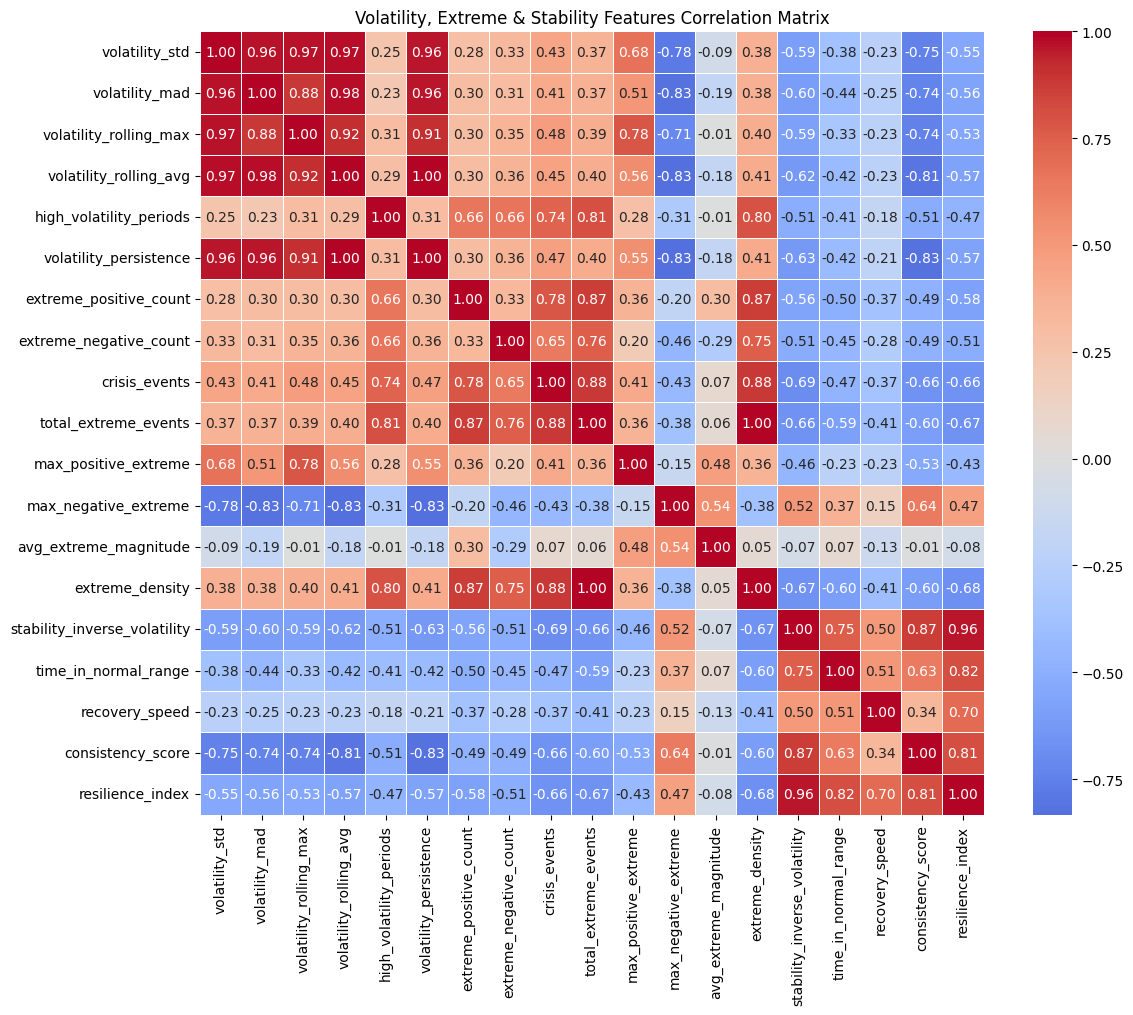

Highly correlated features to consider dropping: ['volatility_mad', 'volatility_rolling_max', 'volatility_rolling_avg', 'volatility_persistence', 'extreme_density', 'resilience_index']
Clean features shape: (202, 14)


In [11]:
# Check for highly correlated features
plt.figure(figsize=(12, 10))
corr_matrix = features_df.drop('country', axis=1).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Volatility, Extreme & Stability Features Correlation Matrix')
plt.tight_layout()
plt.show()

# Remove highly correlated features (>0.9)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

print(f"Highly correlated features to consider dropping: {to_drop}")

# Keep only the clean features
features_clean = features_df.drop(to_drop, axis=1) if to_drop else features_df.copy()
print(f"Clean features shape: {features_clean.shape}")

In [12]:
features_clean

,country,volatility_std,high_volatility_periods,extreme_positive_count,extreme_negative_count,crisis_events,total_extreme_events,max_positive_extreme,max_negative_extreme,avg_extreme_magnitude,stability_inverse_volatility,time_in_normal_range,recovery_speed,consistency_score
0,Haiti,0.733855,11,2,0,0,2,1.80,0.00,1.103333,1.360812,0.816327,0.875000,0.590624
1,Honduras,0.954130,12,2,3,2,5,3.21,-1.72,0.291667,1.046978,0.818182,1.000000,0.511836
2,Hungary,1.282803,7,1,1,2,2,4.83,-2.93,0.363333,0.778936,0.750000,0.666667,0.452044
3,Iceland,0.605546,5,0,0,0,0,0.00,0.00,-1.460000,1.648680,0.928571,1.000000,0.580098
4,Afghanistan,0.718358,3,0,1,1,1,0.00,-2.73,-2.020000,1.390128,0.916667,0.500000,0.659026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,"Venezuela, RB",1.494097,7,4,1,1,5,4.36,-1.65,1.185714,0.668853,0.500000,0.571429,0.473244
198,Samoa,0.690963,5,0,1,0,1,0.00,-1.82,0.253333,1.445163,0.869565,1.000000,0.577125
199,"Yemen, Rep.",3.085626,19,8,2,6,10,8.18,-12.97,1.153636,0.323978,0.685714,0.636364,0.304769
200,Zambia,0.674802,7,2,0,1,2,2.18,0.00,1.525000,1.479724,0.833333,1.000000,0.573852


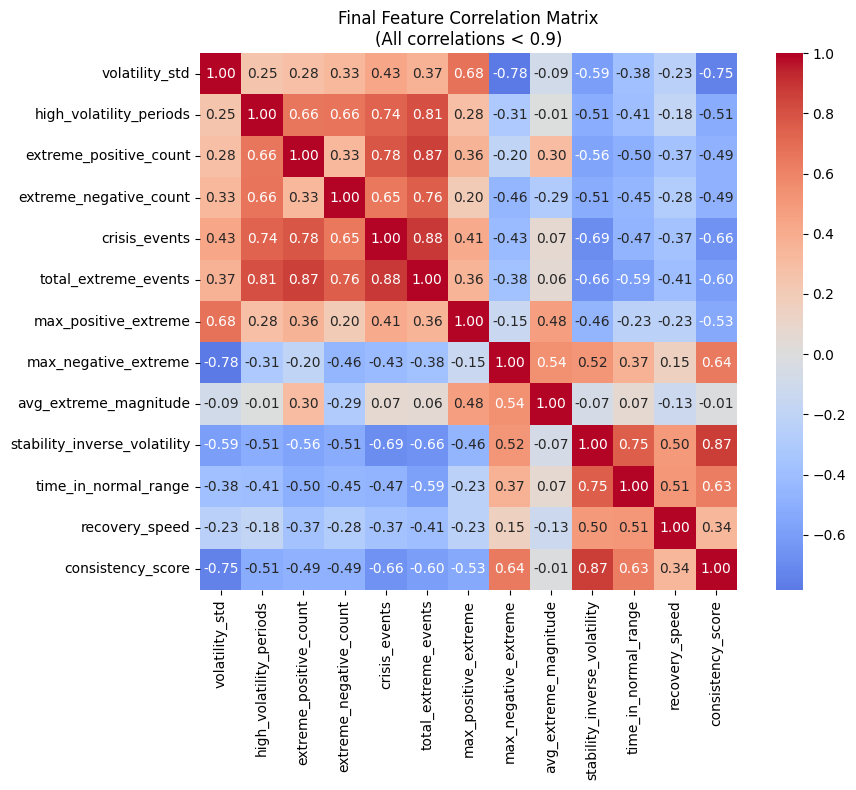

Maximum correlation in final set: 1.0


In [13]:
# Check final correlations
plt.figure(figsize=(10, 8))
final_corr = features_clean.drop('country', axis=1).corr()
sns.heatmap(final_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Final Feature Correlation Matrix\n(All correlations < 0.9)')
plt.tight_layout()
plt.show()

print("Maximum correlation in final set:", final_corr.abs().max().max())

In [14]:

# Separate features and country names
countries = features_clean['country']
X = features_clean.drop('country', axis=1)

print("Original features shape:", X.shape)
print("Features:", list(X.columns))

# Standardize the features (CRUCIAL for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAfter standardization:")
print("Mean:", X_scaled.mean(axis=0).round(2))
print("Std: ", X_scaled.std(axis=0).round(2))

Original features shape: (202, 13)
Features: ['volatility_std', 'high_volatility_periods', 'extreme_positive_count', 'extreme_negative_count', 'crisis_events', 'total_extreme_events', 'max_positive_extreme', 'max_negative_extreme', 'avg_extreme_magnitude', 'stability_inverse_volatility', 'time_in_normal_range', 'recovery_speed', 'consistency_score']

After standardization:
Mean: [-0.  0.  0.  0.  0. -0. -0.  0. -0.  0.  0. -0.  0.]
Std:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [15]:
# Try different PCA thresholds


pca_thresholds = [0.80, 0.85, 0.90, 0.95]
pca_results = {}

for threshold in pca_thresholds:
    pca = PCA(n_components=threshold)
    X_pca = pca.fit_transform(X_scaled)

    print(f"PCA {threshold:.0%} variance: {X_pca.shape[1]} components "
          f"(reduced from {X_scaled.shape[1]})")

    # Test clustering on this reduced set
    scores = []
    for k in range(2, 6):
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = hierarchical.fit_predict(X_pca)
        score = silhouette_score(X_pca, labels)
        scores.append(score)

    pca_results[threshold] = {
        'X_reduced': X_pca,
        'scores': scores,
        'best_score': max(scores),
        'best_k': scores.index(max(scores)) + 2
    }
    print(f"  Best silhouette: {max(scores):.3f} with {scores.index(max(scores)) + 2} clusters")

# Find the best performing reduction
best_threshold = max(pca_results, key=lambda x: pca_results[x]['best_score'])
print(f"\nBest performing: PCA {best_threshold:.0%} variance")

PCA 80% variance: 4 components (reduced from 13)
  Best silhouette: 0.344 with 5 clusters
PCA 85% variance: 5 components (reduced from 13)
  Best silhouette: 0.468 with 2 clusters
PCA 90% variance: 6 components (reduced from 13)
  Best silhouette: 0.476 with 2 clusters
PCA 95% variance: 7 components (reduced from 13)
  Best silhouette: 0.293 with 2 clusters

Best performing: PCA 90% variance


In [16]:
# Continue from your PCA analysis...
print("="*60)
print("CONTINUING WITH BEST PERFORMING PCA CONFIGURATION")
print("="*60)

# 1. DEEP DIVE INTO THE 2 CLUSTERS
print("\n1. 🔍 DEEP DIVE INTO 2 CLUSTERS")

# Get the best configuration
best_data = pca_results[best_threshold]['X_reduced']
best_k = pca_results[best_threshold]['best_k']
best_score = pca_results[best_threshold]['best_score']

print(f"Using: PCA {best_threshold:.0%} variance, {best_k} clusters")
print(f"Silhouette score: {best_score:.3f}")

# Perform final clustering with the best configuration
final_hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
final_labels = final_hierarchical.fit_predict(best_data)

# Add cluster labels to the original features dataframe
results_df = features_clean.copy()
results_df['cluster'] = final_labels

# Analyze cluster characteristics
print("\n📊 CLUSTER CHARACTERISTICS ANALYSIS:")
print("-" * 50)

for cluster_id in range(best_k):
    cluster_data = results_df[results_df['cluster'] == cluster_id]
    cluster_countries = cluster_data['country'].tolist()

    print(f"\n🔵 CLUSTER {cluster_id} ({len(cluster_countries)} countries):")

    # Statistical profile
    profile = cluster_data.mean(numeric_only=True)
    print("   📈 Statistical Profile:")
    print(f"     • Volatility (std): {profile['volatility_std']:.3f}")
    print(f"     • Extreme + events: {profile['extreme_positive_count']:.1f}")
    print(f"     • Extreme - events: {profile['extreme_negative_count']:.1f}")
    print(f"     • Max positive extreme: {profile['max_positive_extreme']:.3f}")
    print(f"     • Stability score: {profile['stability_inverse_volatility']:.3f}")
    print(f"     • Time in normal range: {profile['time_in_normal_range']:.1%}")
    print(f"     • Recovery speed: {profile['recovery_speed']:.3f}")

    # Determine cluster type based on characteristics
    if profile['volatility_std'] < results_df['volatility_std'].mean():
        cluster_type = "Stable Markets"
    else:
        cluster_type = "Volatile Markets"

    print(f"   🏷️  Cluster Type: {cluster_type}")

    # Representative countries
    print(f"   🌍 Representative Countries (first 10):")
    print(f"     {', '.join(cluster_countries[:10])}")

CONTINUING WITH BEST PERFORMING PCA CONFIGURATION

1. 🔍 DEEP DIVE INTO 2 CLUSTERS
Using: PCA 90% variance, 2 clusters
Silhouette score: 0.476

📊 CLUSTER CHARACTERISTICS ANALYSIS:
--------------------------------------------------

🔵 CLUSTER 0 (168 countries):
   📈 Statistical Profile:
     • Volatility (std): 0.900
     • Extreme + events: 1.0
     • Extreme - events: 0.9
     • Max positive extreme: 1.517
     • Stability score: 1.234
     • Time in normal range: 79.7%
     • Recovery speed: 0.752
   🏷️  Cluster Type: Stable Markets
   🌍 Representative Countries (first 10):
     Haiti, Honduras, Hungary, Iceland, Afghanistan, India, Albania, Indonesia, Algeria, Andorra

🔵 CLUSTER 1 (34 countries):
   📈 Statistical Profile:
     • Volatility (std): 3.242
     • Extreme + events: 4.1
     • Extreme - events: 2.4
     • Max positive extreme: 8.695
     • Stability score: 0.502
     • Time in normal range: 66.7%
     • Recovery speed: 0.571
   🏷️  Cluster Type: Volatile Markets
   🌍 Repre

In [32]:
profile.info()

<class 'pandas.core.series.Series'>
Index: 14 entries, volatility_std to cluster
Series name: None
Non-Null Count  Dtype  
--------------  -----  
14 non-null     float64
dtypes: float64(1)
memory usage: 780.0+ bytes




2. 📊 VISUALIZATION
--------------------------------------------------


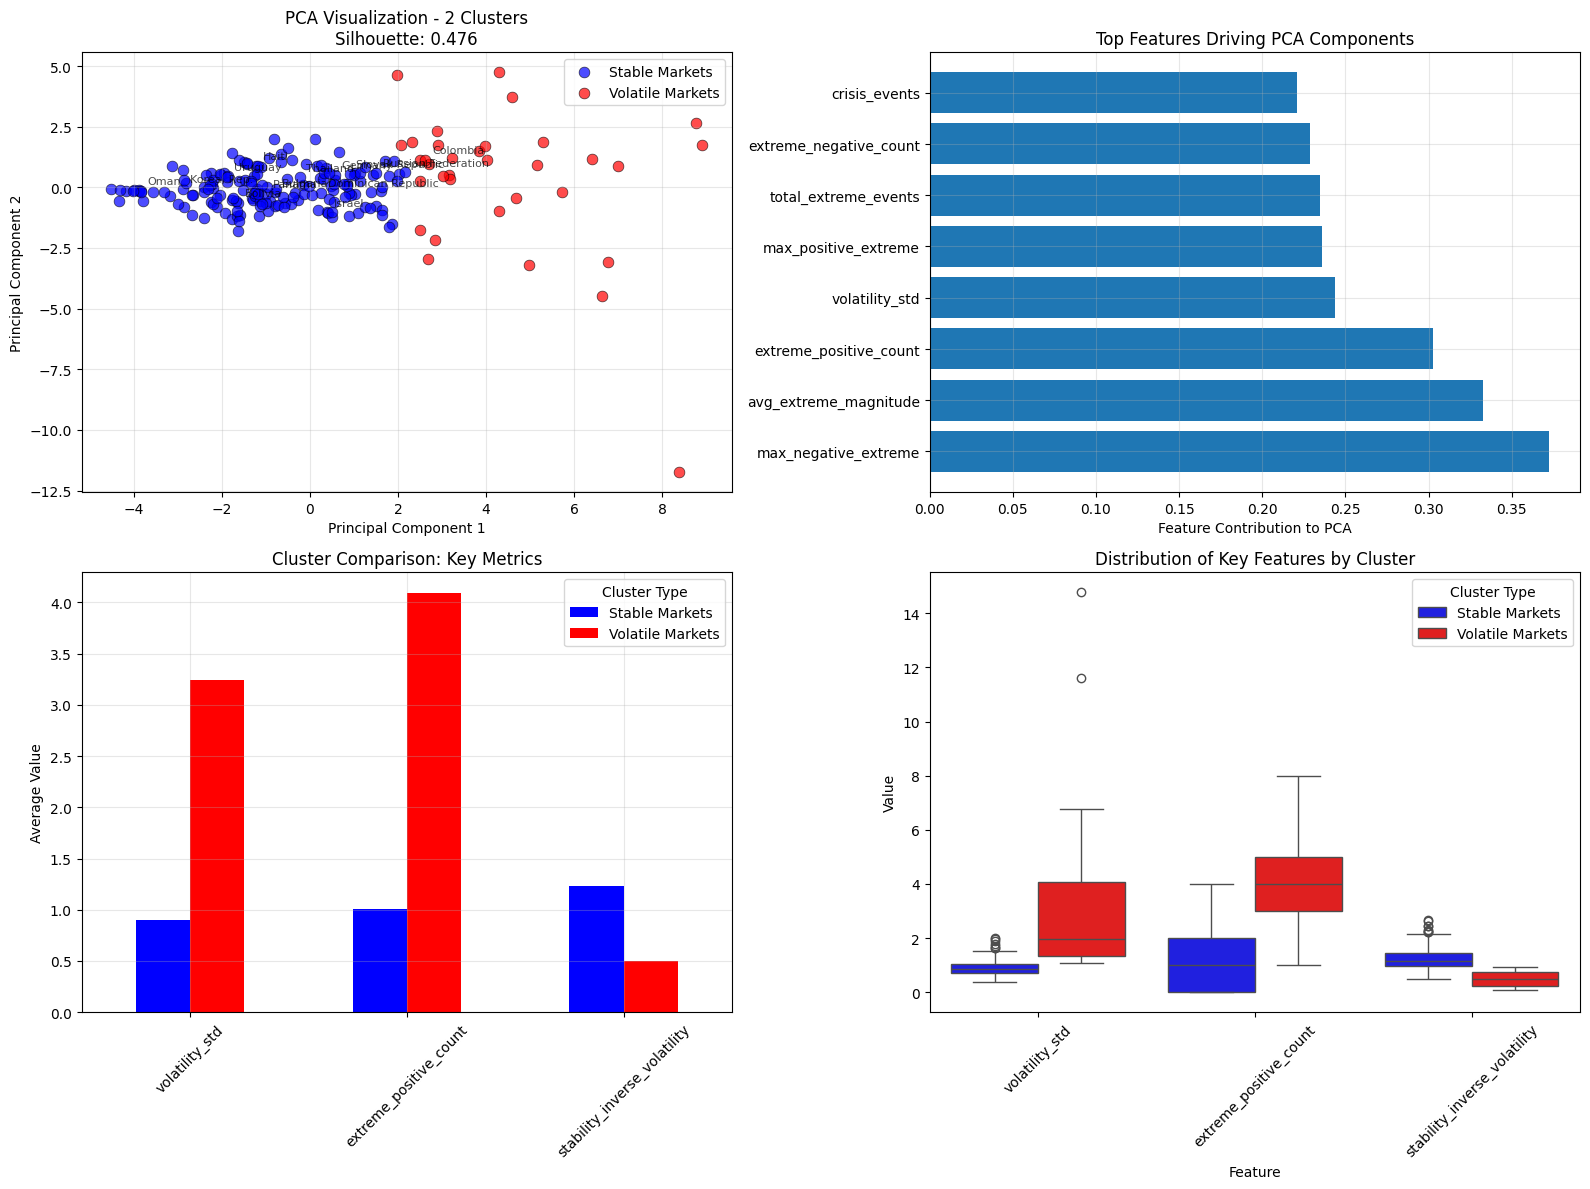

In [17]:
# Add cluster type names to dataframe
cluster_types = {}
for cluster_id in range(best_k):
    cluster_data = results_df[results_df['cluster'] == cluster_id]
    profile = cluster_data.mean(numeric_only=True)
    if profile['volatility_std'] < results_df['volatility_std'].mean():
        cluster_types[cluster_id] = "Stable Markets"
    else:
        cluster_types[cluster_id] = "Volatile Markets"

results_df['cluster_type'] = results_df['cluster'].map(cluster_types)

# 2. VISUALIZE THE CLUSTERS
print("\n\n2. 📊 VISUALIZATION")
print("-" * 50)



# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2.1 PCA Scatter Plot
ax1 = axes[0, 0]
colors = ['blue', 'red']
for cluster_id in range(best_k):
    cluster_mask = results_df['cluster'] == cluster_id
    ax1.scatter(best_data[cluster_mask, 0], best_data[cluster_mask, 1],
                c=colors[cluster_id], label=cluster_types[cluster_id],
                s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add some country labels
for i, country in enumerate(results_df['country']):
    if i % 15 == 0:  # Label every 15th country to avoid overcrowding
        ax1.annotate(country, (best_data[i, 0], best_data[i, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.7)

ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.set_title(f'PCA Visualization - {best_k} Clusters\nSilhouette: {best_score:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)
# 2.2 Feature Importance in PCA
ax2 = axes[0, 1]
pca = PCA(n_components=best_threshold)
pca.fit(X_scaled)

# Get feature contributions to first two components
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'pc1_contribution': abs(pca.components_[0]),
    'pc2_contribution': abs(pca.components_[1])
})
feature_importance['total_contribution'] = feature_importance[['pc1_contribution', 'pc2_contribution']].mean(axis=1)

# Plot feature contributions
top_features = feature_importance.nlargest(8, 'total_contribution')
y_pos = np.arange(len(top_features))
ax2.barh(y_pos, top_features['total_contribution'])
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_features['feature'])
ax2.set_xlabel('Feature Contribution to PCA')
ax2.set_title('Top Features Driving PCA Components')
ax2.grid(True, alpha=0.3)

# 2.3 Cluster Comparison - Volatility and Extremes
ax3 = axes[1, 0]
comparison_data = results_df.groupby('cluster_type').agg({
    'volatility_std': 'mean',
    'extreme_positive_count': 'mean',
    'stability_inverse_volatility': 'mean'
}).T

comparison_data.plot(kind='bar', ax=ax3, color=['blue', 'red'])
ax3.set_title('Cluster Comparison: Key Metrics')
ax3.set_ylabel('Average Value')
ax3.legend(title='Cluster Type')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 2.4 Distribution of Key Features by Cluster
ax4 = axes[1, 1]
features_to_plot = ['volatility_std', 'extreme_positive_count', 'stability_inverse_volatility']
plot_data = results_df.melt(id_vars=['cluster_type'], value_vars=features_to_plot,
                           var_name='Feature', value_name='Value')

sns.boxplot(data=plot_data, x='Feature', y='Value', hue='cluster_type', ax=ax4,
            palette=['blue', 'red'])
ax4.set_title('Distribution of Key Features by Cluster')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Cluster Type')

plt.tight_layout()
plt.show()


In [18]:
# 3. EVALUATION
print("\n\n3. 📈 EVALUATION")
print("-" * 50)



print("📊 STATISTICAL SIGNIFICANCE TESTING:")
print("Testing if differences between clusters are statistically significant...")

significant_features = []
for feature in ['volatility_std', 'extreme_positive_count', 'stability_inverse_volatility']:
    cluster_0_data = results_df[results_df['cluster'] == 0][feature]
    cluster_1_data = results_df[results_df['cluster'] == 1][feature]

    t_stat, p_value = stats.ttest_ind(cluster_0_data, cluster_1_data)

    print(f"\n{feature.upper()}:")
    print(f"  Cluster 0 ({cluster_types[0]}): {cluster_0_data.mean():.3f}")
    print(f"  Cluster 1 ({cluster_types[1]}): {cluster_1_data.mean():.3f}")
    print(f"  T-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")

    if p_value < 0.05:
        significant_features.append(feature)
        print(f"  ✅ Statistically significant (p < 0.05)")
    else:
        print(f"  ❌ Not statistically significant")

print(f"\n🎯 SUMMARY: {len(significant_features)}/{3} key features show statistically significant differences")

# Cluster Quality Assessment
print(f"\n📋 CLUSTER QUALITY ASSESSMENT:")
print(f"Silhouette Score: {best_score:.3f}")
print(f"Interpretation: {'Weak but meaningful structure' if best_score < 0.5 else 'Reasonable structure'}")

# Cluster Separation Assessment
cluster_separation = []
for i in range(best_k):
    for j in range(i+1, best_k):
        cluster_i_data = best_data[results_df['cluster'] == i]
        cluster_j_data = best_data[results_df['cluster'] == j]

        # Calculate distance between cluster centroids
        centroid_i = cluster_i_data.mean(axis=0)
        centroid_j = cluster_j_data.mean(axis=0)
        distance = np.linalg.norm(centroid_i - centroid_j)
        cluster_separation.append(distance)

avg_separation = np.mean(cluster_separation)
print(f"Average inter-cluster distance: {avg_separation:.3f}")

# 4. EXPORT RESULTS
print("\n\n4. 💾 EXPORT RESULTS")
print("-" * 50)


# Create timestamp for filenames
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# 4.1 Export main results CSV
output_filename = f"food_price_clustering_results_{timestamp}.csv"
results_export = results_df[[
    'country', 'cluster', 'cluster_type',
    'volatility_std', 'extreme_positive_count', 'extreme_negative_count',
    'stability_inverse_volatility', 'time_in_normal_range', 'recovery_speed'
]].copy()

# Sort by cluster and volatility for better readability
results_export = results_export.sort_values(['cluster', 'volatility_std'])

results_export.to_csv(output_filename, index=False)
print(f"✅ Results exported to: {output_filename}")

# 4.2 Export cluster summary statistics
cluster_summary = results_df.groupby(['cluster', 'cluster_type']).agg({
    'volatility_std': ['mean', 'std', 'min', 'max'],
    'extreme_positive_count': ['mean', 'std'],
    'stability_inverse_volatility': ['mean', 'std'],
    'country': 'count'
}).round(3)

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.rename(columns={'country_count': 'num_countries'})
cluster_summary = cluster_summary.reset_index()

summary_filename = f"cluster_summary_statistics_{timestamp}.csv"
cluster_summary.to_csv(summary_filename, index=False)
print(f"✅ Cluster summary exported to: {summary_filename}")

# 4.3 Export analysis report
report_data = {
    'analysis_date': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'total_countries': len(results_df),
    'pca_variance_threshold': best_threshold,
    'num_clusters': best_k,
    'silhouette_score': best_score,
    'cluster_0_type': cluster_types[0],
    'cluster_0_count': len(results_df[results_df['cluster'] == 0]),
    'cluster_1_type': cluster_types[1],
    'cluster_1_count': len(results_df[results_df['cluster'] == 1]),
    'statistically_significant_features': significant_features
}

report_df = pd.DataFrame([report_data])
report_filename = f"clustering_analysis_report_{timestamp}.csv"
report_df.to_csv(report_filename, index=False)
print(f"✅ Analysis report exported to: {report_filename}")

# 4.4 Print final summary
print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"📁 Files generated:")
print(f"   • {output_filename} - Main clustering results")
print(f"   • {summary_filename} - Cluster statistics")
print(f"   • {report_filename} - Analysis report")
print(f"\n📊 Key Findings:")
print(f"   • Identified {best_k} distinct clusters of countries")
print(f"   • {cluster_types[0]}: {len(results_df[results_df['cluster'] == 0])} countries")
print(f"   • {cluster_types[1]}: {len(results_df[results_df['cluster'] == 1])} countries")
print(f"   • Clustering quality: {best_score:.3f} silhouette score")
print(f"   • {len(significant_features)} key features show significant differences")

print(f"\n🎯 Next steps:")
print(f"   • Use results for targeted policy recommendations")
print(f"   • Explore geographical patterns in clusters")
print(f"   • Correlate with economic indicators")
print(f"   • Monitor cluster stability over time")

# Display final cluster assignments
print(f"\n🔍 CLUSTER ASSIGNMENTS (first 20 countries):")
print(results_export.head(20).to_string(index=False))



3. 📈 EVALUATION
--------------------------------------------------
📊 STATISTICAL SIGNIFICANCE TESTING:
Testing if differences between clusters are statistically significant...

VOLATILITY_STD:
  Cluster 0 (Stable Markets): 0.900
  Cluster 1 (Volatile Markets): 3.242
  T-statistic: -9.851, p-value: 0.0000
  ✅ Statistically significant (p < 0.05)

EXTREME_POSITIVE_COUNT:
  Cluster 0 (Stable Markets): 1.012
  Cluster 1 (Volatile Markets): 4.088
  T-statistic: -13.341, p-value: 0.0000
  ✅ Statistically significant (p < 0.05)

STABILITY_INVERSE_VOLATILITY:
  Cluster 0 (Stable Markets): 1.234
  Cluster 1 (Volatile Markets): 0.502
  T-statistic: 9.788, p-value: 0.0000
  ✅ Statistically significant (p < 0.05)

🎯 SUMMARY: 3/3 key features show statistically significant differences

📋 CLUSTER QUALITY ASSESSMENT:
Silhouette Score: 0.476
Interpretation: Weak but meaningful structure
Average inter-cluster distance: 5.244


4. 💾 EXPORT RESULTS
--------------------------------------------------
✅ R

In [34]:
results_export.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202 entries, 183 to 81
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       202 non-null    object 
 1   cluster                       202 non-null    int64  
 2   cluster_type                  202 non-null    object 
 3   volatility_std                202 non-null    float64
 4   extreme_positive_count        202 non-null    int32  
 5   extreme_negative_count        202 non-null    int32  
 6   stability_inverse_volatility  202 non-null    float64
 7   time_in_normal_range          202 non-null    float64
 8   recovery_speed                202 non-null    float64
dtypes: float64(4), int32(2), int64(1), object(2)
memory usage: 14.2+ KB


🌍 DEEP LEARNING CLASSIFIER FOR FOOD PRICE STABILITY
🧠 TRAINING DEEP LEARNING CLASSIFIER
Features used: ['volatility_std', 'extreme_positive_count', 'extreme_negative_count', 'stability_inverse_volatility', 'time_in_normal_range', 'recovery_speed']
X shape: (202, 6), y shape: (202,)
Training set: (161, 6)
Test set: (41, 6)
Class distribution - Train: (array([0, 1], dtype=int64), array([134,  27], dtype=int64))
Class distribution - Test: (array([0, 1], dtype=int64), array([34,  7], dtype=int64))

📊 MODEL ARCHITECTURE:
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 128)               896       
                                                                 
 batch_normalization_12 (Bat  (None, 128)              512       
 chNormalization)                                                
                                                            

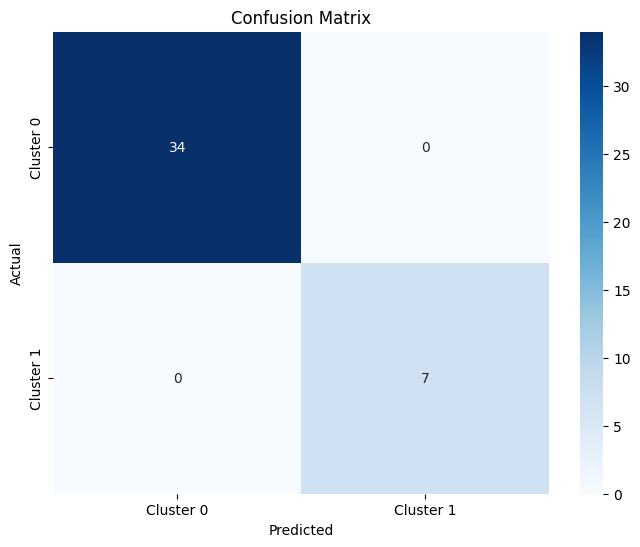


🔍 FEATURE IMPORTANCE ANALYSIS:
⚠️ Permutation importance failed: Could not pickle the task to send it to the workers.
Using alternative feature importance method...
🎯 Test Accuracy: 1.0000

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00         7

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41


🔍 ALTERNATIVE FEATURE IMPORTANCE (Model Weights):


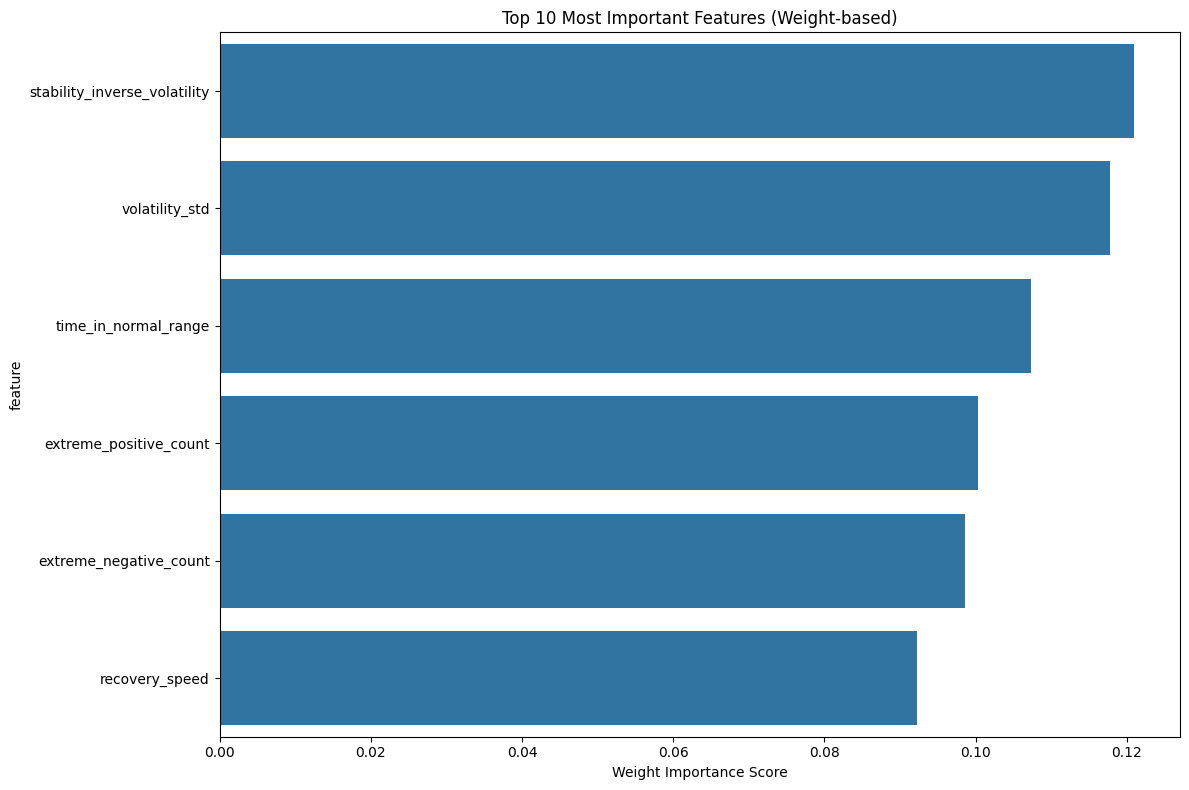


📋 TOP 10 FEATURES BY WEIGHT IMPORTANCE:
                        feature  weight_importance
3  stability_inverse_volatility             0.1210
0                volatility_std             0.1178
4          time_in_normal_range             0.1073
1        extreme_positive_count             0.1003
2        extreme_negative_count             0.0986
5                recovery_speed             0.0922


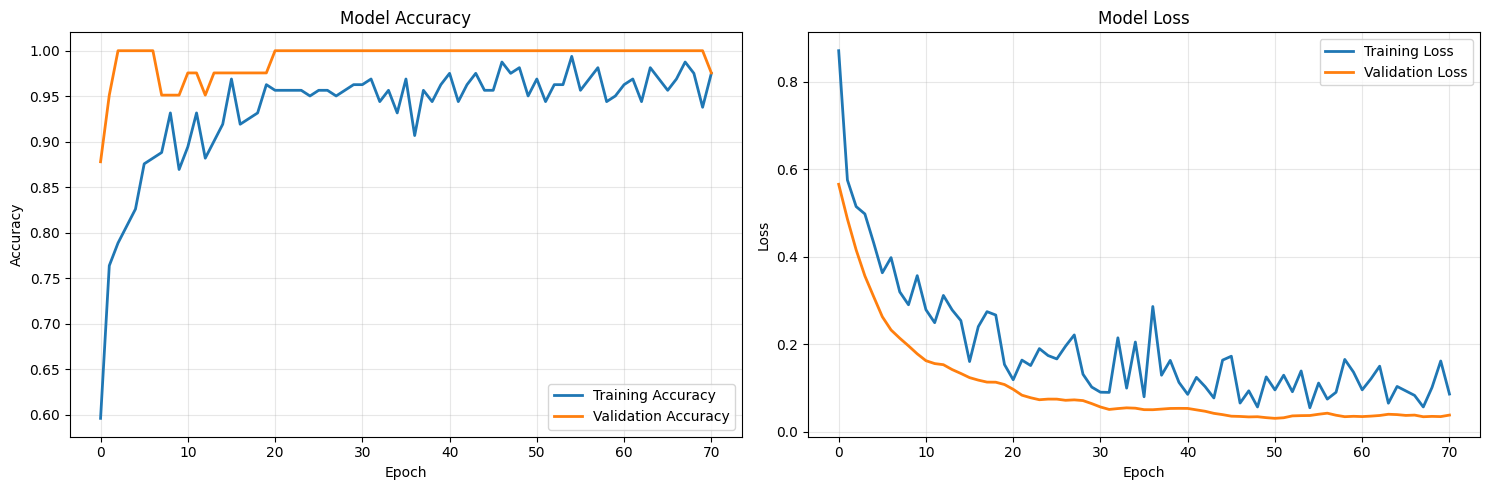


🎉 TRAINING COMPLETED!
Final Test Accuracy: 1.0000


INFO:tensorflow:Assets written to: food_price_classifier\assets


INFO:tensorflow:Assets written to: food_price_classifier\assets


💾 Model saved as 'food_price_classifier.pb'

🔮 EXAMPLE PREDICTION:
Predicted Cluster: Volatile Markets
Confidence: 0.995
Probabilities: [0.99542975 0.00457028]


c:\Users\User\Documents\Thobias\Dok-Perkuliahan dan Pembelajaran Teknik Informatika\DBS CodingCamp Sem VI\dbs-coding-camp-2025\belajarpengembanganmachinelearning\tf310-env\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [28]:

# Create a wrapper class to make Keras model compatible with scikit-learn
class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        # Model is already trained, so just store the data
        return self

    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

def prepare_dl_data():
    df = pd.read_csv("food_price_clustering_results_20251110_192850.csv")

    # Use all features (not just the 3 significant ones)
    feature_columns = [col for col in df.columns
                      if col not in ['country', 'cluster', 'cluster_type']]

    X = df[feature_columns].values
    y = df['cluster'].values  # Use cluster labels as targets

    print(f"Features used: {feature_columns}")
    print(f"X shape: {X.shape}, y shape: {y.shape}")

    return X, y, feature_columns, df

def create_deep_learning_model(input_dim, num_classes):
    """Create a deep neural network model"""

    model = tf.keras.Sequential([
        # Input layer
        tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        # Hidden layers
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),

        # Output layer
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def train_deep_learning_classifier():
    """Train a deep learning classifier on the clustering results"""

    print("🧠 TRAINING DEEP LEARNING CLASSIFIER")
    print("="*50)

    # Prepare data
    X, y, feature_columns, df = prepare_dl_data()

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"Training set: {X_train_scaled.shape}")
    print(f"Test set: {X_test_scaled.shape}")
    print(f"Class distribution - Train: {np.unique(y_train, return_counts=True)}")
    print(f"Class distribution - Test: {np.unique(y_test, return_counts=True)}")

    # Create and train model
    model = create_deep_learning_model(
        input_dim=X_train_scaled.shape[1],
        num_classes=len(np.unique(y))
    )

    print("\n📊 MODEL ARCHITECTURE:")
    model.summary()

    # Callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7
    )

    # Train model
    print("\n🚀 TRAINING MODEL...")
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=200,
        batch_size=16,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    return model, history, scaler, X_test_scaled, y_test, feature_columns, df

def evaluate_model(model, X_test, y_test, feature_columns):
    """Comprehensive model evaluation"""

    print("\n📈 MODEL EVALUATION")
    print("="*50)

    # Predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"🎯 Test Accuracy: {accuracy:.4f}")

    # Classification report
    print("\n📊 CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred,
                              target_names=[f'Cluster {i}' for i in np.unique(y_test)]))

    # Confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Cluster {i}' for i in np.unique(y_test)],
                yticklabels=[f'Cluster {i}' for i in np.unique(y_test)])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Feature importance using permutation importance
    print("\n🔍 FEATURE IMPORTANCE ANALYSIS:")

    # Wrap the Keras model for scikit-learn compatibility
    wrapped_model = KerasClassifierWrapper(model)

    # Calculate permutation importance
    feature_importance = permutation_importance(
        wrapped_model, X_test, y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    # Create importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_columns,
        'importance': feature_importance.importances_mean,
        'std': feature_importance.importances_std
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance_df.head(10), x='importance', y='feature')
    plt.title('Top 10 Most Important Features (Permutation Importance)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print("\n📋 TOP 10 MOST IMPORTANT FEATURES:")
    print(importance_df.head(10).round(4))

    return accuracy, y_pred, importance_df

def plot_training_history(history):
    """Plot training history"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def predict_new_country(model, scaler, new_data, feature_columns):
    """Predict cluster for new country data"""

    # Ensure new_data has the same features
    if isinstance(new_data, dict):
        new_df = pd.DataFrame([new_data])
        # Ensure all feature columns are present
        for col in feature_columns:
            if col not in new_df.columns:
                new_df[col] = 0  # Or appropriate default value
        new_data_scaled = scaler.transform(new_df[feature_columns])
    else:
        new_data_scaled = scaler.transform(new_data.reshape(1, -1))

    # Predict
    prediction_proba = model.predict(new_data_scaled, verbose=0)
    predicted_cluster = np.argmax(prediction_proba, axis=1)[0]
    confidence = np.max(prediction_proba)

    return predicted_cluster, confidence, prediction_proba[0]

# Alternative feature importance method (if permutation importance still has issues)
def alternative_feature_importance(model, feature_columns):
    """Alternative feature importance using model weights"""

    print("\n🔍 ALTERNATIVE FEATURE IMPORTANCE (Model Weights):")

    # Get weights from the first layer
    first_layer_weights = model.layers[0].get_weights()[0]

    # Calculate importance as mean absolute weight for each feature
    weight_importance = np.mean(np.abs(first_layer_weights), axis=1)

    weight_df = pd.DataFrame({
        'feature': feature_columns,
        'weight_importance': weight_importance
    }).sort_values('weight_importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=weight_df.head(10), x='weight_importance', y='feature')
    plt.title('Top 10 Most Important Features (Weight-based)')
    plt.xlabel('Weight Importance Score')
    plt.tight_layout()
    plt.show()

    print("\n📋 TOP 10 FEATURES BY WEIGHT IMPORTANCE:")
    print(weight_df.head(10).round(4))

    return weight_df

# Main execution
print("🌍 DEEP LEARNING CLASSIFIER FOR FOOD PRICE STABILITY")
print("="*60)

# Train the model
model, history, scaler, X_test, y_test, feature_columns, df = train_deep_learning_classifier()

# Evaluate
try:
    accuracy, y_pred, importance_df = evaluate_model(model, X_test, y_test, feature_columns)
except Exception as e:
    print(f"⚠️ Permutation importance failed: {e}")
    print("Using alternative feature importance method...")

    # Basic evaluation without permutation importance
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"🎯 Test Accuracy: {accuracy:.4f}")
    print("\n📊 CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred))

    # Use alternative feature importance
    importance_df = alternative_feature_importance(model, feature_columns)

# Plot training history
plot_training_history(history)

print(f"\n🎉 TRAINING COMPLETED!")
print(f"Final Test Accuracy: {accuracy:.4f}")

# Save the model for later use
model.save('food_price_classifier')
print("💾 Model saved as 'food_price_classifier.pb'")

# Example prediction
print(f"\n🔮 EXAMPLE PREDICTION:")
sample_data = {
    'volatility_std': 1.5,
    'extreme_positive_count': 2.0,
    'stability_inverse_volatility': 0.8,
    'time_in_normal_range': 0.6,
    'recovery_speed': 0.7
}

cluster, confidence, probabilities = predict_new_country(model, scaler, sample_data, feature_columns)
cluster_name = "Volatile Markets" if cluster == 0 else "Stable Markets"
print(f"Predicted Cluster: {cluster_name}")
print(f"Confidence: {confidence:.3f}")
print(f"Probabilities: {probabilities}")


In [24]:
!pip freeze > requirements.txt

In [25]:
!cat requirements.txt

absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.11.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.1
altair==5.5.0
annotated-doc==0.0.3
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.11.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.2
arrow==1.4.0
arviz==0.22.0
astropy==7.1.1
astropy-iers-data==0.2025.11.3.0.38.37
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.5
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.5
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.28.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.0
blobfile==3.1.0
blosc2==3.11.0
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.10.5
cffi==2.0.0
chardet==5.2.0
charset-normalizer==3

In [29]:
# ADD THIS EXPORT SECTION AT THE END OF YOUR NOTEBOOK
# (after all your preprocessing code runs)

print("\n" + "="*60)
print("EXPORTING PREPROCESSING OBJECTS")
print("="*60)

# Export the scaler you already created

joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler exported as 'scaler.pkl'")

# Export feature columns

feature_columns = list(X.columns)  # This should already exist from your code
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)
print("✅ Feature columns exported as 'feature_columns.json'")
print("   Features:", feature_columns)

# For PCA - since you tested multiple thresholds, export the best one
best_pca = pca_results[best_threshold]['pca_object']
joblib.dump(best_pca, 'pca.pkl')
print("✅ Best PCA object exported as 'pca.pkl'")
print(f"   PCA variance threshold: {best_threshold:.0%}")
print(f"   Number of components: {best_pca.n_components_}")

print("\n📁 Files ready for Streamlit:")
print("   - scaler.pkl")
print("   - pca.pkl")
print("   - feature_columns.json")


EXPORTING PREPROCESSING OBJECTS
✅ Scaler exported as 'scaler.pkl'
✅ Feature columns exported as 'feature_columns.json'
   Features: ['volatility_std', 'high_volatility_periods', 'extreme_positive_count', 'extreme_negative_count', 'crisis_events', 'total_extreme_events', 'max_positive_extreme', 'max_negative_extreme', 'avg_extreme_magnitude', 'stability_inverse_volatility', 'time_in_normal_range', 'recovery_speed', 'consistency_score']


KeyError: 'pca_object'

In [30]:
# ADD THIS EXPORT SECTION AT THE END OF YOUR NOTEBOOK

print("\n" + "="*60)
print("EXPORTING PREPROCESSING OBJECTS")
print("="*60)

# Export the scaler you already created
import joblib
import json

joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler exported as 'scaler.pkl'")

# Export feature columns
feature_columns = list(X.columns)
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)
print("✅ Feature columns exported as 'feature_columns.json'")
print("   Features:", feature_columns)

# Recreate the best PCA (since we don't have the stored object)
best_pca = PCA(n_components=best_threshold)
best_pca.fit(X_scaled)  # Fit on the same scaled data
joblib.dump(best_pca, 'pca.pkl')
print("✅ Best PCA recreated and exported as 'pca.pkl'")
print(f"   PCA variance threshold: {best_threshold:.0%}")
print(f"   Number of components: {best_pca.n_components_}")

print("\n📁 Files ready for Streamlit:")
print("   - scaler.pkl")
print("   - pca.pkl")
print("   - feature_columns.json")


EXPORTING PREPROCESSING OBJECTS
✅ Scaler exported as 'scaler.pkl'
✅ Feature columns exported as 'feature_columns.json'
   Features: ['volatility_std', 'high_volatility_periods', 'extreme_positive_count', 'extreme_negative_count', 'crisis_events', 'total_extreme_events', 'max_positive_extreme', 'max_negative_extreme', 'avg_extreme_magnitude', 'stability_inverse_volatility', 'time_in_normal_range', 'recovery_speed', 'consistency_score']
✅ Best PCA recreated and exported as 'pca.pkl'
   PCA variance threshold: 90%
   Number of components: 6

📁 Files ready for Streamlit:
   - scaler.pkl
   - pca.pkl
   - feature_columns.json


In [28]:
!cat feature_columns.json

["volatility_std", "high_volatility_periods", "extreme_positive_count", "extreme_negative_count", "crisis_events", "total_extreme_events", "max_positive_extreme", "max_negative_extreme", "avg_extreme_magnitude", "stability_inverse_volatility", "time_in_normal_range", "recovery_speed", "consistency_score"]

In [29]:
!pip show numpy

Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRI